In [2]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1. Load data (reduced vocab → less memory)
num_words = 5000
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

In [3]:
# 2. Vectorize (memory optimized)
def vectorize(data):
    x = np.zeros((len(data), num_words), dtype='float32')
    for i, seq in enumerate(data):
        x[i, seq] = 1.0
    return x

x_train = vectorize(x_train)
x_test = vectorize(x_test)

# 3. Model
model = keras.Sequential([
    keras.Input(shape=(num_words,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# 4. Compile
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# 5. Train (simple validation split)
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.2
)

# 6. Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7760 - loss: 0.5284 - val_accuracy: 0.8662 - val_loss: 0.3906
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8873 - loss: 0.3220 - val_accuracy: 0.8810 - val_loss: 0.3132
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9093 - loss: 0.2590 - val_accuracy: 0.8858 - val_loss: 0.2906
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9197 - loss: 0.2267 - val_accuracy: 0.8878 - val_loss: 0.2846
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9280 - loss: 0.2057 - val_accuracy: 0.8900 - val_loss: 0.2820
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 246us/step - accuracy: 0.8824 - loss: 0.2915
Test Accuracy: 0.8823599815368652


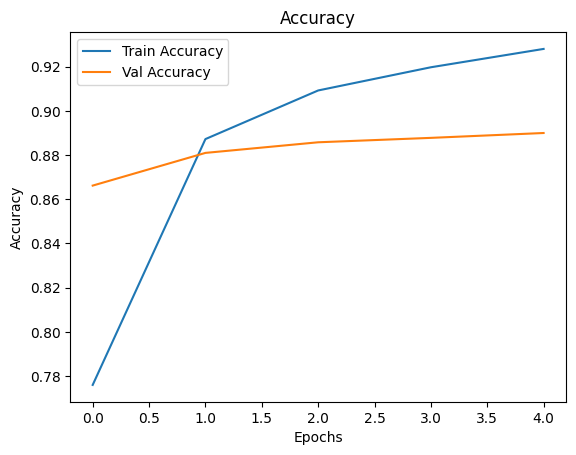

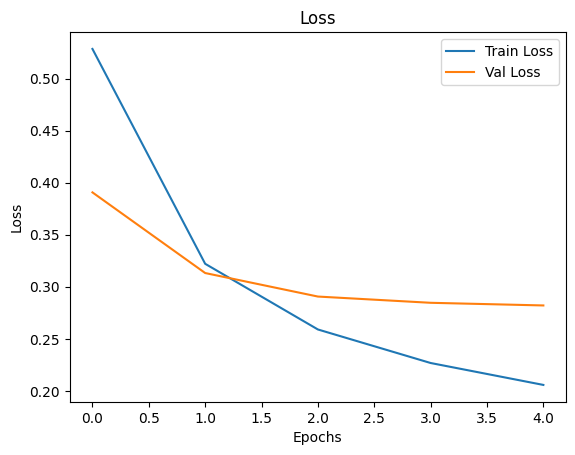

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Sample Predictions: [[0.2993505 ]
 [0.9998463 ]
 [0.61090404]
 [0.69059014]
 [0.9461158 ]]


In [4]:
# -------- GRAPH 1: Accuracy --------
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# -------- GRAPH 2: Loss --------
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 7. Predictions
predictions = model.predict(x_test[:5])
print("Sample Predictions:", predictions)